# Returns and Validation - VN30 Stock Data

Notebook `03_returns_and_validation.ipynb` reads the clean panel from `data/processed/clean_ohlcv.csv`, computes `log_return`, builds `return_matrix_clean.csv`, and performs intermediate validation before correlation, clustering, and Markowitz.

This is **not** a pure EDA notebook. The statistics and plots here are diagnostic checks to validate the handoff artifact after preprocess.

## Goals

1. Read the clean input panel from `clean_ohlcv.csv`
2. Run quick validation after preprocess
3. Compute `log_return` for each ticker
4. Run quick diagnostics on returns and existing flags
5. Build the return matrix `(T x N)`
6. Validate the return matrix before notebook 04
7. Export `return_matrix_clean.csv`


In [1]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# Safe matplotlib config for Vietnamese rendering when needed
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans", "Liberation Sans", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

print("Library import completed")


Library import completed


## Step 1: Load the clean panel and prepare the data


In [2]:
# Load clean_ohlcv.csv
PROJECT_ROOT = Path.cwd().parent
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
file_path = DATA_PROCESSED / "clean_ohlcv.csv"
output_file = DATA_PROCESSED / "return_matrix_clean.csv"
EXPECTED_TICKERS = 29
CORE_RETURN_COLS = ["date", "ticker", "close"]
REQUIRED_PREPROCESS_COLS = ["range_ratio", "is_range_outlier", "is_volume_outlier"]

df = pd.read_csv(file_path)

# Basic dtype normalization
df["date"] = pd.to_datetime(df["date"])
df["ticker"] = df["ticker"].str.upper()

# Sort before any return calculation
df = df.sort_values(["ticker", "date"]).reset_index(drop=True)

print(f"Input file: {file_path}")
print(f"Canonical output: {output_file}")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Expected tickers: {EXPECTED_TICKERS}")
print()
print("First 5 rows:")
df.head()


Input file: d:\Archive\NCKH\CODE\vn30-ver1 - Copy\.worktrees\returns-validation-contract\data\processed\clean_ohlcv.csv
Canonical output: d:\Archive\NCKH\CODE\vn30-ver1 - Copy\.worktrees\returns-validation-contract\data\processed\return_matrix_clean.csv
Shape: (41644, 10)
Columns: ['date', 'ticker', 'open', 'high', 'low', 'close', 'volume', 'range_ratio', 'is_range_outlier', 'is_volume_outlier']
Expected tickers: 29

First 5 rows:


,date,ticker,open,high,low,close,volume,range_ratio,is_range_outlier,is_volume_outlier
0,2020-01-02,ACB,6.58,6.64,6.55,6.64,1163109,1.355422,False,False
1,2020-01-03,ACB,6.64,6.70,6.61,6.64,1055528,1.355422,False,False
2,2020-01-06,ACB,6.64,6.64,6.49,6.49,1286035,2.311248,False,False
3,2020-01-07,ACB,6.49,6.55,6.49,6.49,1050934,0.924499,False,False
4,2020-01-08,ACB,6.49,6.49,6.35,6.38,2304937,2.194357,False,False


## Step 2: Validate the clean input panel


In [3]:
print("=" * 60)
print("VALIDATE CLEAN INPUT PANEL")
print("=" * 60)

print()
print("1. Basic information:")
print(f"   - Shape: {df.shape}")
print(f"   - Start date: {df['date'].min().date()}")
print(f"   - End date: {df['date'].max().date()}")
print(f"   - Trading days: {df['date'].nunique():,}")

tickers = sorted(df["ticker"].unique())
print()
print(f"2. Ticker list (n={len(tickers)}):")
print(f"   {', '.join(tickers)}")

has_ssb = "SSB" in tickers
print()
print(f"   - Contains SSB: {has_ssb}")
if not has_ssb:
    print("   - CONFIRMED: SSB has been removed")

print()
print("3. Missing-value check:")
nan_counts = df.isna().sum()
print(nan_counts[nan_counts > 0] if (nan_counts > 0).any() else "   - No NaN values found")

missing_core = int(df[CORE_RETURN_COLS].isna().sum().sum())
print()
print(f"   - Missing values in core columns {CORE_RETURN_COLS}: {missing_core}")
if missing_core == 0:
    print("   - Core columns for return calculation are valid")

missing_required_preprocess = [col for col in REQUIRED_PREPROCESS_COLS if col not in df.columns]
print()
print(f"   - Required preprocess columns for notebook 03 diagnostics: {REQUIRED_PREPROCESS_COLS}")
print(f"   - Missing required preprocess columns: {missing_required_preprocess}")
if not missing_required_preprocess:
    print("   - Derived preprocess columns required by notebook 03 are present")

print()
print("   - Notebook 02 handoff note:")
print("     input file comes from notebook 02")
print("     file is expected to be a cleaned balanced panel")
print("     derived preprocessing columns are part of the contract for notebook 03 diagnostics")

print()
print("4. Tickers per day:")
n_ticker_by_date = df.groupby("date")["ticker"].nunique()
print(n_ticker_by_date.describe())

n_incomplete = int((n_ticker_by_date < EXPECTED_TICKERS).sum())
print()
print(f"   - Days with fewer than {EXPECTED_TICKERS} tickers: {n_incomplete}")
if n_incomplete > 0:
    print(f"   - Minimum tickers on an incomplete day: {n_ticker_by_date.min()}")
else:
    print(f"   - Balanced panel confirmed at {EXPECTED_TICKERS} tickers per day")

print()
print("   First 5 dates:")
print(n_ticker_by_date.head())
print()
print("   Last 5 dates:")
print(n_ticker_by_date.tail())

assert "SSB" not in df["ticker"].unique(), "SSB should not appear in clean panel input"
assert df[CORE_RETURN_COLS].isna().sum().sum() == 0, "Missing values remain in date/ticker/close"
assert not missing_required_preprocess, (
    "Notebook 03 expects the balanced-panel clean_ohlcv.csv exported by notebook 02 "
    f"with derived columns {REQUIRED_PREPROCESS_COLS}; missing {missing_required_preprocess}"
)
assert n_incomplete == 0, "Clean panel is not balanced by date at the expected ticker count"

print()
print("Clean input validation completed")


VALIDATE CLEAN INPUT PANEL

1. Basic information:
   - Shape: (41644, 10)
   - Start date: 2020-01-02
   - End date: 2025-11-28
   - Trading days: 1,436

2. Ticker list (n=29):
   ACB, BCM, BID, CTG, DGC, FPT, GAS, GVR, HDB, HPG, LPB, MBB, MSN, MWG, PLX, SAB, SHB, SSI, STB, TCB, TPB, VCB, VHM, VIB, VIC, VJC, VNM, VPB, VRE

   - Contains SSB: False
   - CONFIRMED: SSB has been removed

3. Missing-value check:
   - No NaN values found

   - Missing values in core columns ['date', 'ticker', 'close']: 0
   - Core columns for return calculation are valid

   - Required preprocess columns for notebook 03 diagnostics: ['range_ratio', 'is_range_outlier', 'is_volume_outlier']
   - Missing required preprocess columns: []
   - Derived preprocess columns required by notebook 03 are present

   - Notebook 02 handoff note:
     input file comes from notebook 02
     file is expected to be a cleaned balanced panel
     derived preprocessing columns are part of the contract for notebook 03 diagnostics

## Step 3: Quick diagnostics on features and preprocess flags


In [4]:
print("=" * 60)
print("QUICK FEATURE DIAGNOSTICS")
print("=" * 60)

print()
print("1. Descriptive statistics (close, volume, range_ratio):")
print(df[["close", "volume", "range_ratio"]].describe())

print()
print("2. Outlier flags:")

if "is_range_outlier" in df.columns:
    range_outlier_counts = df["is_range_outlier"].value_counts()
    print()
    print("   is_range_outlier:")
    print(range_outlier_counts)
    if True in range_outlier_counts.index:
        pct = range_outlier_counts[True] / len(df) * 100
        print(f"   -> {pct:.2f}% of rows are range outliers")
    elif 1 in range_outlier_counts.index:
        pct = range_outlier_counts[1] / len(df) * 100
        print(f"   -> {pct:.2f}% of rows are range outliers")

if "is_volume_outlier" in df.columns:
    volume_outlier_counts = df["is_volume_outlier"].value_counts()
    print()
    print("   is_volume_outlier:")
    print(volume_outlier_counts)
    if True in volume_outlier_counts.index:
        pct = volume_outlier_counts[True] / len(df) * 100
        print(f"   -> {pct:.2f}% of rows are volume outliers")
    elif 1 in volume_outlier_counts.index:
        pct = volume_outlier_counts[1] / len(df) * 100
        print(f"   -> {pct:.2f}% of rows are volume outliers")

print()
print("Feature diagnostics completed")


QUICK FEATURE DIAGNOSTICS

1. Descriptive statistics (close, volume, range_ratio):
              close        volume   range_ratio
count  41644.000000  4.164400e+04  41644.000000
mean      38.838646  7.171485e+06      2.755344
std       28.852623  1.116573e+07      1.780400
min        2.110000  1.000000e+02      0.000000
25%       16.190000  1.209479e+06      1.534493
50%       29.300000  3.264207e+06      2.256804
75%       57.255000  8.728841e+06      3.424036
max      219.100000  2.497607e+08     19.339623

2. Outlier flags:

   is_range_outlier:
is_range_outlier
False    41227
True       417
Name: count, dtype: int64
   -> 1.00% of rows are range outliers

   is_volume_outlier:
is_volume_outlier
False    41227
True       417
Name: count, dtype: int64
   -> 1.00% of rows are volume outliers

Feature diagnostics completed


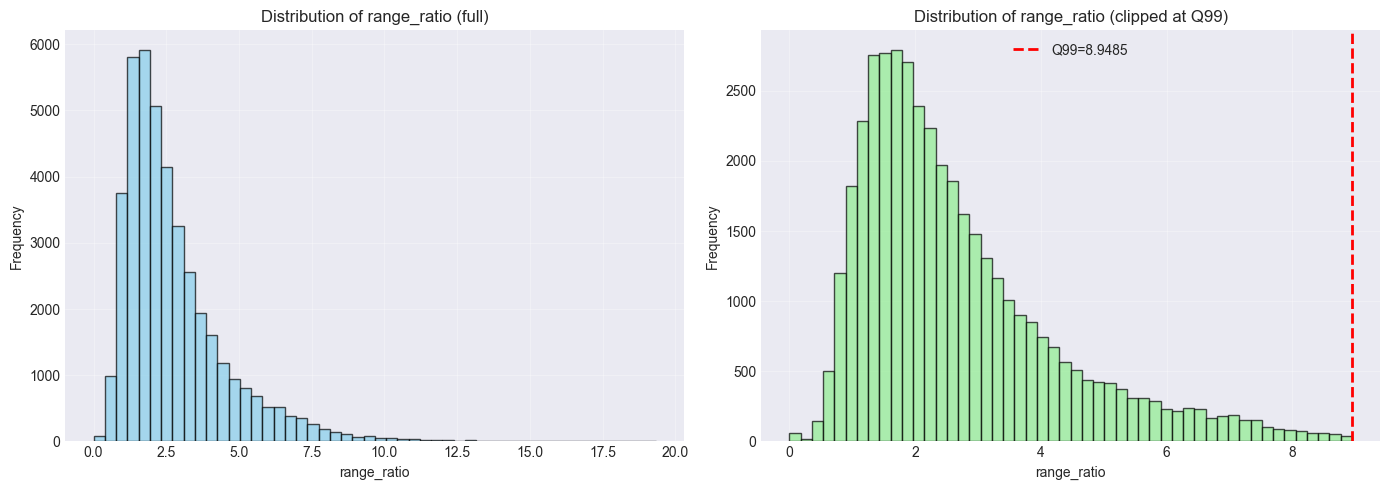

range_ratio diagnostic plot completed


In [5]:
# Plot range_ratio distribution for diagnostics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(df["range_ratio"], bins=50, alpha=0.7, color="skyblue", edgecolor="black")
ax.set_title("Distribution of range_ratio (full)")
ax.set_xlabel("range_ratio")
ax.set_ylabel("Frequency")
ax.grid(True, alpha=0.3)

ax = axes[1]
q99 = df["range_ratio"].quantile(0.99)
clipped_data = df[df["range_ratio"] <= q99]["range_ratio"]
ax.hist(clipped_data, bins=50, alpha=0.7, color="lightgreen", edgecolor="black")
ax.axvline(q99, color="red", linestyle="--", linewidth=2, label=f"Q99={q99:.4f}")
ax.set_title("Distribution of range_ratio (clipped at Q99)")
ax.set_xlabel("range_ratio")
ax.set_ylabel("Frequency")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("range_ratio diagnostic plot completed")


## Step 4: Compute `log_return` by ticker

`log_return` is computed on data sorted by `ticker, date`. The `NaN` values produced at this step correspond to the **first row of each price series**, so dropping them is mathematically normal rather than a data-quality problem.


In [6]:
print("=" * 60)
print("COMPUTE LOG-RETURN BY TICKER")
print("=" * 60)

df = df.sort_values(["ticker", "date"]).reset_index(drop=True)

df["log_return"] = (
    df.groupby("ticker")["close"]
    .transform(lambda s: np.log(s / s.shift(1)))
)

n_tickers = int(df["ticker"].nunique())
n_nan_log_return = int(df["log_return"].isna().sum())

print()
print("1. log_return calculation:")
print(f"   - Input rows: {len(df):,}")
print(f"   - Tickers: {n_tickers}")
print(f"   - NaN rows in log_return: {n_nan_log_return}")
print(f"   - Expected NaN rows (first row of each ticker): {n_tickers}")

if n_nan_log_return == n_tickers:
    print("   - NaN count matches the number of tickers")
else:
    print("   - WARNING: NaN count does not match ticker count")

assert n_nan_log_return == n_tickers, "Unexpected number of NaN rows after log-return calculation"

df_ret = df.dropna(subset=["log_return"]).copy()

print()
print("2. After dropping first-row NaN values:")
print("   - Dropped rows correspond to the first observation of each ticker")
print(f"   - Remaining rows: {len(df_ret):,}")
print(f"   - Remaining tickers: {df_ret['ticker'].nunique()}")

n_inf = int(np.isinf(df_ret["log_return"]).sum())
if n_inf > 0:
    print()
    print(f"   - WARNING: Found {n_inf} infinite log-return values")
else:
    print()
    print("   - No infinite log-return values found")

assert n_inf == 0, "Infinite values detected in log_return"

print()
print("3. Preview df_ret:")
df_ret.head(10)


COMPUTE LOG-RETURN BY TICKER

1. log_return calculation:
   - Input rows: 41,644
   - Tickers: 29
   - NaN rows in log_return: 29
   - Expected NaN rows (first row of each ticker): 29
   - NaN count matches the number of tickers

2. After dropping first-row NaN values:
   - Dropped rows correspond to the first observation of each ticker
   - Remaining rows: 41,615
   - Remaining tickers: 29

   - No infinite log-return values found

3. Preview df_ret:


,date,ticker,open,high,low,close,volume,range_ratio,is_range_outlier,is_volume_outlier,log_return
1,2020-01-03,ACB,6.64,6.70,6.61,6.64,1055528,1.355422,False,False,0.000000
2,2020-01-06,ACB,6.64,6.64,6.49,6.49,1286035,2.311248,False,False,-0.022849
3,2020-01-07,ACB,6.49,6.55,6.49,6.49,1050934,0.924499,False,False,0.000000
4,2020-01-08,ACB,6.49,6.49,6.35,6.38,2304937,2.194357,False,False,-0.017094
5,2020-01-09,ACB,6.41,6.52,6.41,6.46,1422248,1.702786,False,False,0.012461
6,2020-01-10,ACB,6.49,6.67,6.49,6.55,2371501,2.748092,False,False,0.013836
7,2020-01-13,ACB,6.61,6.61,6.55,6.61,1523181,0.907716,False,False,0.009119
8,2020-01-14,ACB,6.61,6.78,6.61,6.78,2851982,2.507375,False,False,0.025393
9,2020-01-15,ACB,6.78,6.78,6.70,6.72,1158657,1.190476,False,False,-0.008889
10,2020-01-16,ACB,6.72,6.93,6.72,6.90,2819687,3.043478,False,False,0.026433


## Step 5: Quick diagnostics on `log_return`

This block is only a quick diagnostic summary of the return distribution. The top-5 volatile tickers shown here are **not** an asset-selection rule.


In [7]:
print("=" * 60)
print("QUICK LOG-RETURN DIAGNOSTICS")
print("=" * 60)

print()
print("1. log_return statistics by ticker:")
ret_stats = df_ret.groupby("ticker")["log_return"].agg(["mean", "median", "std", "min", "max"])
print(ret_stats.head(10))

print()
print("2. Top 5 highest-volatility tickers (diagnostic only):")
print(ret_stats.sort_values("std", ascending=False).head())

print()
print("3. Top 5 lowest-volatility tickers:")
print(ret_stats.sort_values("std", ascending=True).head())

print()
print("4. Top 10 absolute log_return values:")
top_abs = df_ret.reindex(
    df_ret["log_return"].abs().sort_values(ascending=False).index
).head(10)
cols_to_show = ["date", "ticker", "log_return", "range_ratio"]
if "is_range_outlier" in df_ret.columns:
    cols_to_show.append("is_range_outlier")
if "is_volume_outlier" in df_ret.columns:
    cols_to_show.append("is_volume_outlier")
print(top_abs[cols_to_show])

print()
print("log_return diagnostics completed")


QUICK LOG-RETURN DIAGNOSTICS

1. log_return statistics by ticker:
            mean    median       std       min       max
ticker                                                  
ACB     0.000903  0.000000  0.018966 -0.181226  0.091038
BCM     0.000610  0.000000  0.024538 -0.159860  0.118404
BID     0.000235  0.000000  0.022525 -0.326237  0.067890
CTG     0.000862  0.001104  0.022311 -0.206019  0.098136
DGC     0.001790  0.000000  0.025859 -0.083679  0.152522
FPT     0.001054  0.000000  0.018127 -0.107584  0.067544
GAS     0.000055  0.000000  0.020612 -0.259288  0.067701
GVR     0.000706  0.001720  0.029326 -0.132858  0.095999
HDB     0.001047  0.000000  0.022045 -0.277967  0.067366
HPG     0.000812  0.000000  0.022224 -0.153719  0.078145

2. Top 5 highest-volatility tickers (diagnostic only):
            mean    median       std       min       max
ticker                                                  
GVR     0.000706  0.001720  0.029326 -0.132858  0.095999
SSI     0.001114  0.000

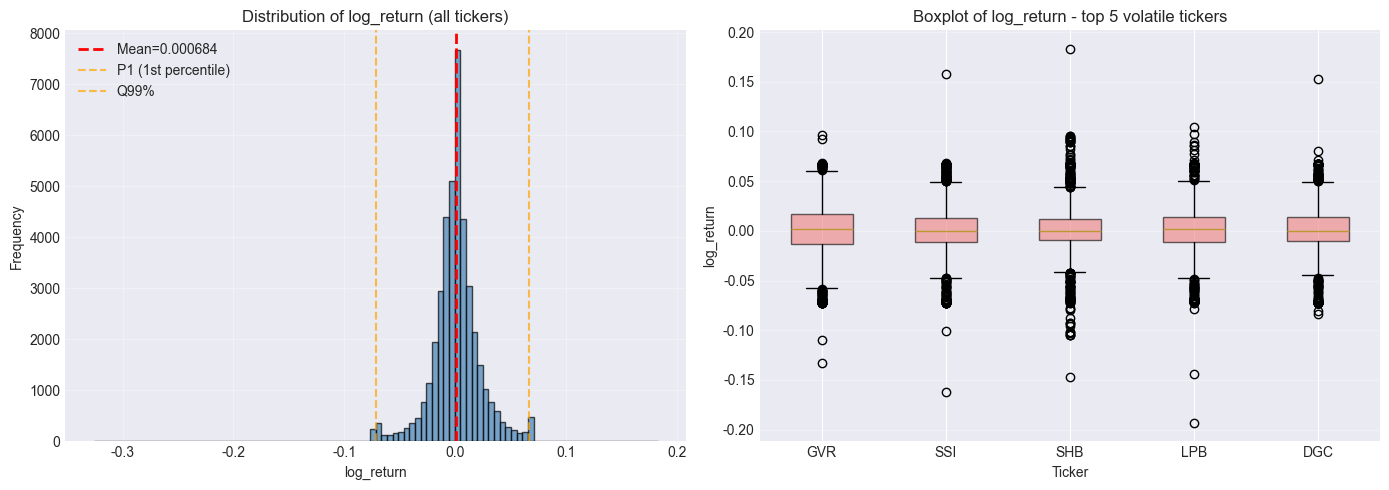

log_return plots completed


In [8]:
# Diagnostic plots for log_return
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(df_ret["log_return"], bins=100, alpha=0.7, color="steelblue", edgecolor="black")
ax.axvline(
    df_ret["log_return"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean={df_ret['log_return'].mean():.6f}",
)
ax.axvline(
    df_ret["log_return"].quantile(0.01),
    color="orange",
    linestyle="--",
    alpha=0.7,
    label="P1 (1st percentile)",
)
ax.axvline(
    df_ret["log_return"].quantile(0.99),
    color="orange",
    linestyle="--",
    alpha=0.7,
    label="Q99%",
)
ax.set_title("Distribution of log_return (all tickers)")
ax.set_xlabel("log_return")
ax.set_ylabel("Frequency")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
top5_volatile = ret_stats.sort_values("std", ascending=False).head(5).index.tolist()
data_to_plot = [
    df_ret[df_ret["ticker"] == t]["log_return"].values for t in top5_volatile
]
bp = ax.boxplot(data_to_plot, labels=top5_volatile, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("lightcoral")
    patch.set_alpha(0.6)
ax.set_title("Boxplot of log_return - top 5 volatile tickers")
ax.set_xlabel("Ticker")
ax.set_ylabel("log_return")
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print("log_return plots completed")


## Step 6: Build the return matrix `(T x N)`

The return matrix is pivoted from `log_return` with `date x ticker`. This is the in-memory artifact used for validation before exporting the canonical CSV handoff for notebook 04.


In [9]:
print("=" * 60)
print("BUILD RETURN MATRIX (T x N)")
print("=" * 60)

print()
print("1. Pivot return matrix:")
ret_matrix = df_ret.pivot(index="date", columns="ticker", values="log_return")

print(f"   - Initial in-memory shape: {ret_matrix.shape}")
print(f"   - Time periods (T): {ret_matrix.shape[0]}")
print(f"   - Tickers (N): {ret_matrix.shape[1]}")

print()
print("2. Check NaN values after pivot:")
n_rows_with_nan = int(ret_matrix.isna().any(axis=1).sum())
n_total_nan = int(ret_matrix.isna().sum().sum())

print(f"   - Total NaN values: {n_total_nan}")
print(f"   - Days with NaN values: {n_rows_with_nan}")

if n_rows_with_nan > 0:
    print()
    print(f"   - Drop {n_rows_with_nan} day(s) with NaN values to keep a full matrix for downstream")
    ret_matrix_clean = ret_matrix.dropna(axis=0, how="any").copy()
    print()
    print("3. After dropping NaN days:")
    print(f"   - New shape: {ret_matrix_clean.shape}")
    print(f"   - Remaining days: {ret_matrix_clean.shape[0]}")
    print(f"   - Remaining NaN values: {ret_matrix_clean.isna().sum().sum()}")
else:
    print()
    print("   - 0 day dropped at this step; the matrix is already complete after pivot")
    ret_matrix_clean = ret_matrix.copy()

assert ret_matrix_clean.isna().sum().sum() == 0, "Return matrix still contains NaN after cleaning"

print()
print("4. Preview return_matrix_clean:")
print(ret_matrix_clean.head())

print()
print("Return matrix build completed")


BUILD RETURN MATRIX (T x N)

1. Pivot return matrix:
   - Initial in-memory shape: (1435, 29)
   - Time periods (T): 1435
   - Tickers (N): 29

2. Check NaN values after pivot:
   - Total NaN values: 0
   - Days with NaN values: 0

   - 0 day dropped at this step; the matrix is already complete after pivot

4. Preview return_matrix_clean:
ticker           ACB       BCM       BID       CTG       DGC       FPT  \
date                                                                     
2020-01-03  0.000000 -0.010509 -0.004164 -0.009178 -0.016737 -0.017151   
2020-01-06 -0.022849 -0.010253 -0.019537  0.002125 -0.019887 -0.010628   
2020-01-07  0.000000 -0.027992  0.019537  0.016146  0.019887  0.019241   
2020-01-08 -0.017094 -0.006836  0.008687 -0.002091 -0.050479 -0.022646   
2020-01-09  0.012461 -0.007267  0.052740  0.036318  0.039164  0.014034   

ticker           GAS       GVR       HDB       HPG  ...       TCB       TPB  \
date                                                ...      

## Step 7: Export the canonical artifact `return_matrix_clean.csv`

In memory, the return matrix has shape `(T x N)`. When exported with `index=True`, `date` is saved as the index, so reading the CSV back with `pd.read_csv` will usually look like `T x (N + 1)` because of the extra `date` column.


In [10]:
print("=" * 60)
print("EXPORT RETURN MATRIX")
print("=" * 60)

ret_matrix_clean.to_csv(output_file, index=True)

print()
print(f"Saved file: {output_file}")
print(f"   - In-memory shape: {ret_matrix_clean.shape} (T x N)")
print(
    f"   - Index (date): {ret_matrix_clean.index.min().date()} to {ret_matrix_clean.index.max().date()}"
)
print(f"   - Columns (tickers): {list(ret_matrix_clean.columns)}")
print(
    f"   - Reading the CSV back with pd.read_csv will usually show shape ~ ({ret_matrix_clean.shape[0]}, {ret_matrix_clean.shape[1] + 1}) because date is stored as the index"
)

print()
print("Return matrix export completed")


EXPORT RETURN MATRIX

Saved file: d:\Archive\NCKH\CODE\vn30-ver1 - Copy\.worktrees\returns-validation-contract\data\processed\return_matrix_clean.csv
   - In-memory shape: (1435, 29) (T x N)
   - Index (date): 2020-01-03 to 2025-11-28
   - Columns (tickers): ['ACB', 'BCM', 'BID', 'CTG', 'DGC', 'FPT', 'GAS', 'GVR', 'HDB', 'HPG', 'LPB', 'MBB', 'MSN', 'MWG', 'PLX', 'SAB', 'SHB', 'SSI', 'STB', 'TCB', 'TPB', 'VCB', 'VHM', 'VIB', 'VIC', 'VJC', 'VNM', 'VPB', 'VRE']
   - Reading the CSV back with pd.read_csv will usually show shape ~ (1435, 30) because date is stored as the index

Return matrix export completed


## Step 8: Correlation diagnostics before notebook 04

The correlation block in this notebook is only an intermediate diagnostic step to inspect the structure of the return matrix. The canonical artifact handed off by notebook 03 remains `data/processed/return_matrix_clean.csv`.


In [11]:
print("=" * 60)
print("CORRELATION DIAGNOSTICS BEFORE NOTEBOOK 04")
print("=" * 60)

print()
print("1. Compute correlation matrix:")
corr_matrix = ret_matrix_clean.corr()

print(f"   - Shape: {corr_matrix.shape}")

print()
print("2. Off-diagonal statistics on unique pairs only:")
mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
off_diag = corr_matrix.where(mask).stack()

print(f"   - Unique pairs: {len(off_diag)}")
print(f"   - Min: {off_diag.min():.4f}")
print(f"   - Max: {off_diag.max():.4f}")
print(f"   - Mean: {off_diag.mean():.4f}")
print(f"   - Median: {off_diag.median():.4f}")
print(f"   - Std: {off_diag.std():.4f}")

print()
print("3. Additional diagnostics:")
n_high_corr = int((off_diag > 0.7).sum())
n_low_corr = int((off_diag < 0.3).sum())
n_negative = int((off_diag < 0).sum())

print(f"   - Unique pairs with corr > 0.7: {n_high_corr} ({n_high_corr/len(off_diag)*100:.1f}%)")
print(f"   - Unique pairs with corr < 0.3: {n_low_corr} ({n_low_corr/len(off_diag)*100:.1f}%)")
print(f"   - Unique pairs with corr < 0: {n_negative} ({n_negative/len(off_diag)*100:.1f}%)")

print()
print("4. Preview correlation matrix:")
print(corr_matrix.iloc[:5, :5])

print()
print("Correlation diagnostics completed")


CORRELATION DIAGNOSTICS BEFORE NOTEBOOK 04

1. Compute correlation matrix:
   - Shape: (29, 29)

2. Off-diagonal statistics on unique pairs only:
   - Unique pairs: 406
   - Min: 0.1779
   - Max: 0.7974
   - Mean: 0.4356
   - Median: 0.4213
   - Std: 0.1197

3. Additional diagnostics:
   - Unique pairs with corr > 0.7: 7 (1.7%)
   - Unique pairs with corr < 0.3: 49 (12.1%)
   - Unique pairs with corr < 0: 0 (0.0%)

4. Preview correlation matrix:
ticker       ACB       BCM       BID       CTG       DGC
ticker                                                  
ACB     1.000000  0.348485  0.658787  0.688589  0.383107
BCM     0.348485  1.000000  0.344388  0.353095  0.344354
BID     0.658787  0.344388  1.000000  0.735670  0.364274
CTG     0.688589  0.353095  0.735670  1.000000  0.408454
DGC     0.383107  0.344354  0.364274  0.408454  1.000000

Correlation diagnostics completed


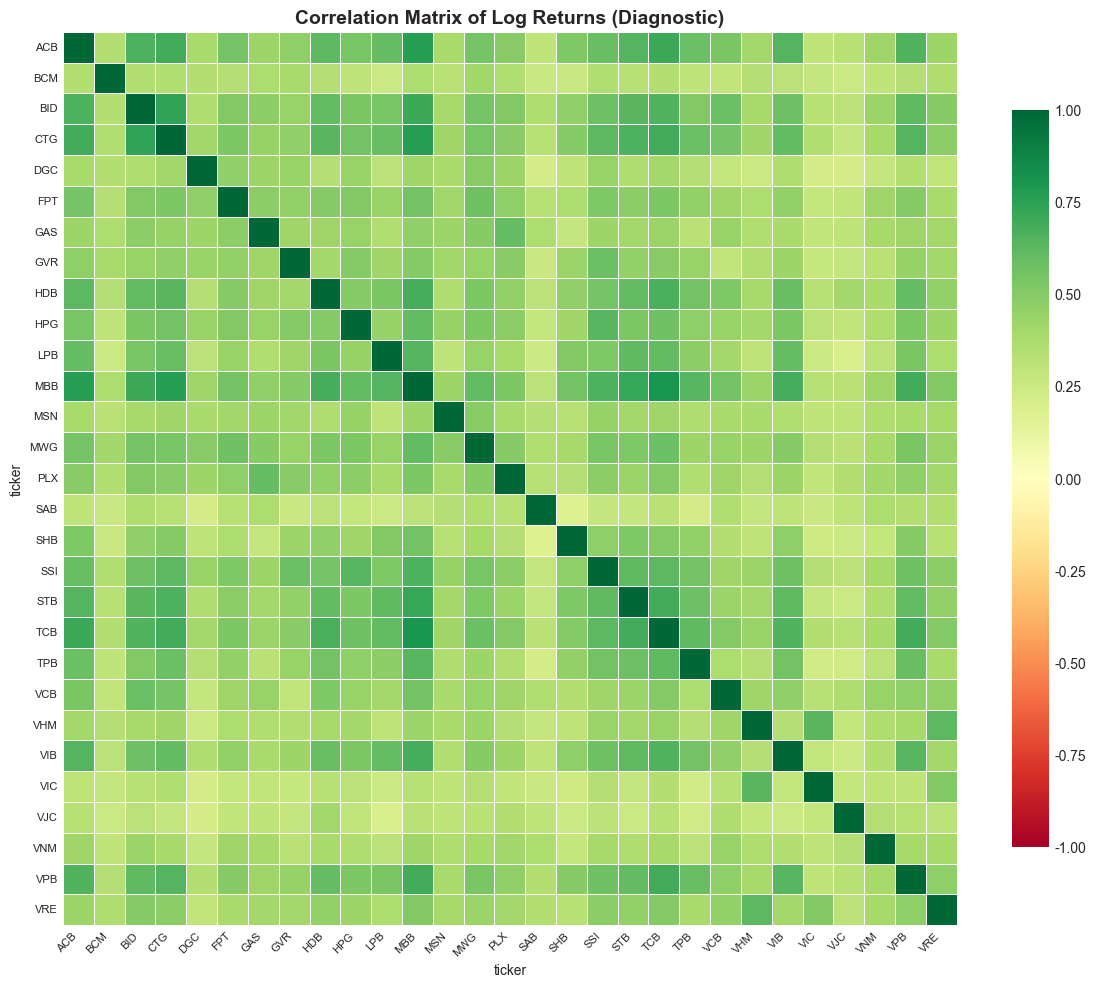

Correlation heatmap diagnostic completed


In [12]:
# Diagnostic heatmap only: no file export here because the canonical handoff artifact is return_matrix_clean.csv
fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    cmap="RdYlGn",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    xticklabels=True,
    yticklabels=True,
    ax=ax,
)

ax.set_title("Correlation Matrix of Log Returns (Diagnostic)", fontsize=14, fontweight="bold")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

print("Correlation heatmap diagnostic completed")


## Final summary and downstream handoff

The final block below confirms that the clean input panel is valid, `log_return` has been computed for the full universe, and the artifact handed off to notebook 04 is `data/processed/return_matrix_clean.csv`.


In [13]:
print("=" * 80)
print("RETURNS AND VALIDATION SUMMARY")
print("=" * 80)

summary = """CLEAN INPUT PANEL:
  - Source file: data/processed/clean_ohlcv.csv
  - Tickers: {tickers}
  - No SSB: {no_ssb}
  - No missing values in core columns: {no_missing}
  - Balanced by day: {balanced}

LOG-RETURN:
  - Successfully computed for all {n_tickers} tickers
  - First-row NaN values dropped: {n_nan_log_return}
  - No infinite values: {no_inf}

RETURN MATRIX:
  - In-memory shape: {shape} (T x N)
  - No NaN values: {matrix_no_nan}
  - Canonical handoff artifact: data/processed/return_matrix_clean.csv

CORRELATION DIAGNOSTICS:
  - Mean correlation: {corr_mean:.4f}
  - Median correlation: {corr_median:.4f}
  - Min/Max: {corr_min:.4f} / {corr_max:.4f}
  - Unique pairs counted once: {pairs}

NEXT STEP IN NOTEBOOK 04:
  1. Compute the covariance matrix
  2. Compute the correlation distance: d = sqrt(2 * (1 - corr))
  3. Run clustering
  4. Hand off artifacts to downstream portfolio steps
""".format(
    tickers=df["ticker"].nunique(),
    no_ssb=(not has_ssb),
    no_missing=(df[CORE_RETURN_COLS].isna().sum().sum() == 0),
    balanced=(n_incomplete == 0),
    n_tickers=n_tickers,
    n_nan_log_return=n_nan_log_return,
    no_inf=(n_inf == 0),
    shape=ret_matrix_clean.shape,
    matrix_no_nan=(ret_matrix_clean.isna().sum().sum() == 0),
    corr_mean=off_diag.mean(),
    corr_median=off_diag.median(),
    corr_min=off_diag.min(),
    corr_max=off_diag.max(),
    pairs=len(off_diag),
)

print(summary)
print("=" * 80)
print("RETURNS AND VALIDATION COMPLETED")
print("=" * 80)


RETURNS AND VALIDATION SUMMARY
CLEAN INPUT PANEL:
  - Source file: data/processed/clean_ohlcv.csv
  - Tickers: 29
  - No SSB: True
  - No missing values in core columns: True
  - Balanced by day: True

LOG-RETURN:
  - Successfully computed for all 29 tickers
  - First-row NaN values dropped: 29
  - No infinite values: True

RETURN MATRIX:
  - In-memory shape: (1435, 29) (T x N)
  - No NaN values: True
  - Canonical handoff artifact: data/processed/return_matrix_clean.csv

CORRELATION DIAGNOSTICS:
  - Mean correlation: 0.4356
  - Median correlation: 0.4213
  - Min/Max: 0.1779 / 0.7974
  - Unique pairs counted once: 406

NEXT STEP IN NOTEBOOK 04:
  1. Compute the covariance matrix
  2. Compute the correlation distance: d = sqrt(2 * (1 - corr))
  3. Run clustering
  4. Hand off artifacts to downstream portfolio steps

RETURNS AND VALIDATION COMPLETED
